In [2]:
from keras.layers import *
from keras.models import Model, load_model
from keras.datasets import mnist
from keras.datasets import fashion_mnist
from keras.callbacks import ReduceLROnPlateau
from keras import regularizers
from keras import optimizers
from keras import backend as K
import scipy
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea
import pandas as pd
import numpy as np

In [3]:
(x_train, _), (x_test, _) = fashion_mnist.load_data()

x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

In [4]:
# полносвязная автоэнкодер
x_train_fc = x_train.reshape(-1, 784)
x_test_fc = x_test.reshape(-1, 784)

In [4]:
input_img = Input(shape=(784,))

# encoder
encoded = Dense(784, activation='relu')(input_img)
encoded = Dense(256, activation='relu')(encoded)
encoded = Dense(128, activation='relu')(encoded) 
encoded = Dense(64, activation='relu')(encoded)
encoded = Dense(2, activation='linear')(encoded)


In [5]:
# decoder
decoded = Dense(64, activation='relu')(encoded)
decoded = Dense(128, activation='relu')(decoded)
decoded = Dense(256, activation='relu')(decoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [6]:
autoencoder_fc = Model(input_img, decoded)
autoencoder_fc.compile(optimizer='adam', loss='binary_crossentropy')

print(autoencoder_fc.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 784)            │       615,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,100,706 (4.20 MB)

 Trainable params: 1,100,706 (4.20 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
history_fc = autoencoder_fc.fit(x_train_fc, x_train_fc,
                epochs=20, 
                batch_size=256, 
                shuffle=True,
                validation_data=(x_test_fc, x_test_fc))

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.3879 - val_loss: 0.3455
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3379 - val_loss: 0.3335
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3288 - val_loss: 0.3294
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3261 - val_loss: 0.3270
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3241 - val_loss: 0.3258
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3241 - val_loss: 0.3237
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3233 - val_loss: 0.3290
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3251 - val_loss: 0.3255
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3237 - val_loss: 0.3246
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3225 - val_loss: 0.3245
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.3225 - val_loss: 0.3276
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

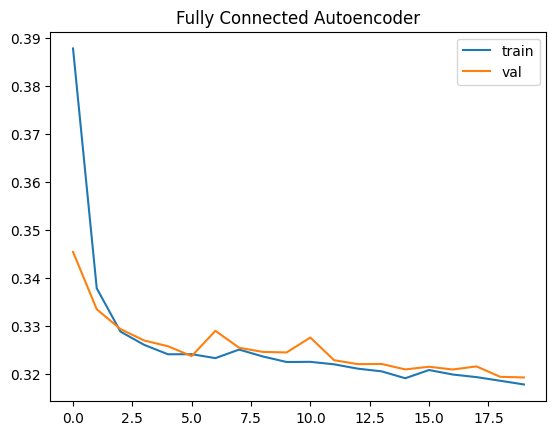

In [8]:
plt.plot(history_fc.history['loss'])
plt.plot(history_fc.history['val_loss'])
plt.title("Fully Connected Autoencoder")
plt.legend(["train","val"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


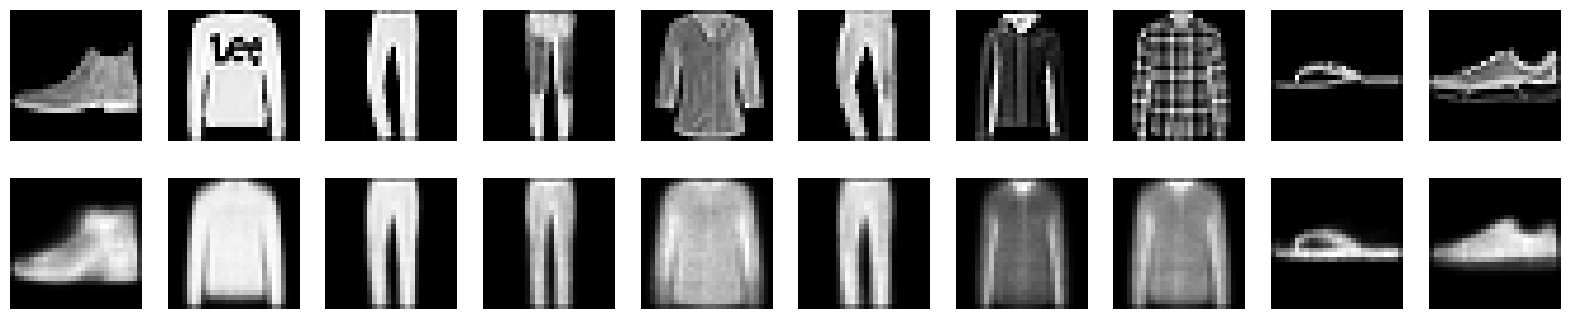

In [9]:
decoded_imgs = autoencoder_fc.predict(x_test_fc)

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [5]:
# CNN автоэнкодер
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

In [6]:
input_img = Input(shape=(28, 28, 1)) 

# encoder
x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2))(x)

x = Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)
encoded = Dense(2, activation='linear')(x)

encoder = Model(input_img, encoded)

    

In [7]:
# decoder
encoded_inputs = Input(shape=(2,))

x = Dense(7*7*16, activation='relu')(encoded_inputs)
x = Reshape((7,7,16))(x)

x = UpSampling2D((2,2))(x)
x = Conv2D(16, (3,3), activation='relu', padding='same')(x)

x = UpSampling2D((2,2))(x)
decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

decoder = Model(encoded_inputs, decoded)


In [8]:
x = encoder(input_img)
x = decoder(x)
model = Model(inputs=input_img, outputs=x)
model.compile(optimizer=optimizers.Adam(1e-3), loss='binary_crossentropy', metrics=['accuracy', 'mse'])

print(model.summary())

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 2)              │         6,514 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_1 (Functional)       │ (None, 28, 28, 1)      │         4,817 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,331 (44.26 KB)

 Trainable params: 11,331 (44.26 KB)

 Non-trainable params: 0 (0.00 B)

None


In [9]:
clr = ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=3,
        min_delta=0.01,
        cooldown=0,
        min_lr=1e-7,
        verbose=1)

model.fit(
        x_train,
        x_train,
        batch_size=256,
        epochs=50,
        shuffle=True,
        validation_data=(x_test, x_test),
        callbacks=[clr])

Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 19s 58ms/step - accuracy: 0.4926 - loss: 0.4317 - mse: 0.0661 - val_accuracy: 0.4928 - val_loss: 0.3646 - val_mse: 0.0410 - learning_rate: 0.0010
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.4953 - loss: 0.3561 - mse: 0.0390 - val_accuracy: 0.4948 - val_loss: 0.3532 - val_mse: 0.0374 - learning_rate: 0.0010
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.4963 - loss: 0.3493 - mse: 0.0368 - val_accuracy: 0.4957 - val_loss: 0.3486 - val_mse: 0.0359 - learning_rate: 0.0010
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.4969 - loss: 0.3459 - mse: 0.0357 - val_accuracy: 0.4962 - val_loss: 0.3465 - val_mse: 0.0353 - learning_rate: 0.0010
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 47ms/step - accuracy: 0.4973 - loss: 0.3436 - mse: 0.0349 - val_accuracy: 0.4950 - val_loss: 0.3441 - val_mse: 0.0345 - learning_rate: 0.0010
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - accuracy: 0.49

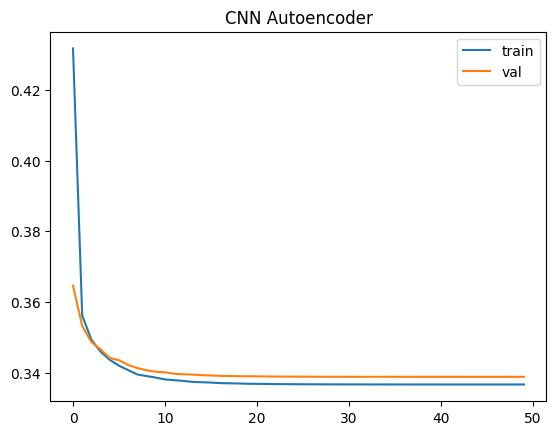

In [10]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

plt.title("CNN Autoencoder")
plt.legend(["train","val"])
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


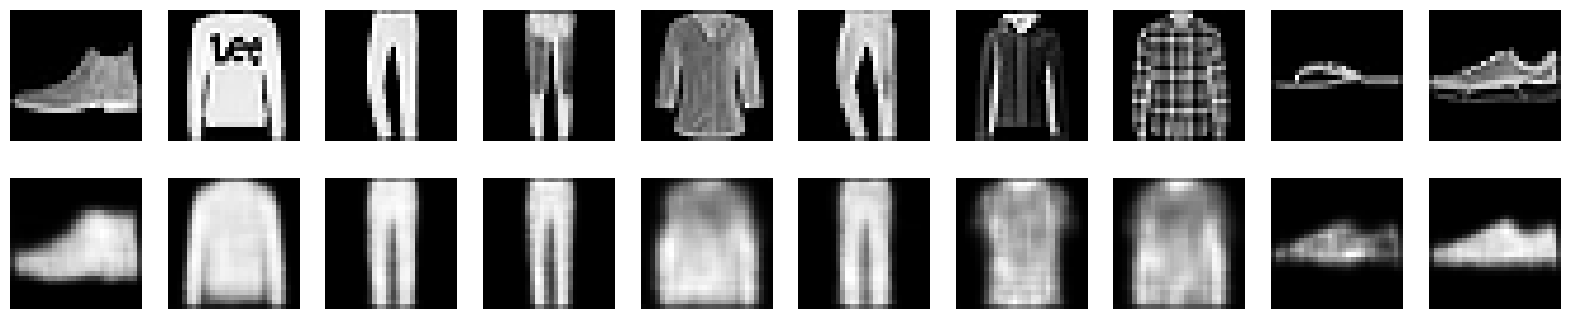

In [11]:
decoded_imgs = model.predict(x_test_cnn)

plt.figure(figsize=(20,4))

for i in range(10):

    ax = plt.subplot(2,10,i+1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis("off")

    ax = plt.subplot(2,10,i+11)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [12]:
from ipywidgets import interactive, FloatSlider
from IPython.display import display

z_test = encoder.predict(x_test_cnn, verbose=0)

z1_min, z1_max = float(z_test[:, 0].min()), float(z_test[:, 0].max())
z2_min, z2_max = float(z_test[:, 1].min()), float(z_test[:, 1].max())

def plot_latent(z1, z2):
    latent = np.array([[z1, z2]], dtype=np.float32)
    decoded = decoder.predict(latent, verbose=0)[0]

    plt.figure(figsize=(4, 4))
    plt.imshow(decoded.squeeze(), cmap='gray')
    plt.axis('off')
    plt.title(f"z1={z1:.2f}, z2={z2:.2f}")
    plt.show()

interactive_plot = interactive(
    plot_latent,
    z1=FloatSlider(min=z1_min, max=z1_max, step=0.01,
                   value=(z1_min + z1_max)/2, description='z1'),
    z2=FloatSlider(min=z2_min, max=z2_max, step=0.01,
                   value=(z2_min + z2_max)/2, description='z2')
)

display(interactive_plot)

interactive(children=(FloatSlider(value=3.0777666568756104, description='z1', max=10.31348991394043, min=-4.15…